# Great Tit Sightings + VIIRS Nightlights Overlay
This notebook loads VIIRS nightlight data from an HDF5 file and overlays it with eBird Great Tit sightings on an interactive Folium map.

In [1]:
import pandas as pd
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import matplotlib
import matplotlib.colors as mcolors
import base64
from io import BytesIO
from PIL import Image

## 1. Load Bird Sightings Data

In [2]:
df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])
df['YEAR'] = df['OBSERVATION DATE'].dt.year
df['MONTH'] = df['OBSERVATION DATE'].dt.month
df = df.sort_values(by=['OBSERVATION DATE']).reset_index(drop=True)

print(f"Loaded {len(df):,} bird sighting records")
df.head()

Loaded 878,189 bird sighting records


,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,...,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,YEAR,MONTH
0,Little Stint,Calidris minuta,1.0,NaN,United Kingdom,GB,England,GB-ENG,Norfolk,GB-ENG-NFK,...,L939078,H,52.963714,0.607011,2017-01-01,obsr791929,S280408599,Traveling,2017,1
1,Red Knot,Calidris canutus,2.0,NaN,United Kingdom,GB,England,GB-ENG,Cornwall,GB-ENG-CON,...,L26753199,P,50.534788,-4.873002,2017-01-01,obsr1298083,S199055232,Historical,2017,1
2,Sanderling,Calidris alba,10.0,NaN,Portugal,PT,Faro,PT-08,LoulÃ©,PT-08-LO,...,L1099654,H,37.025529,-7.997092,2017-01-01,obsr1410639,S62604795,Historical,2017,1
3,Green Sandpiper,Tringa ochropus,1.0,NaN,France,FR,Occitanie,FR-OCC,HÃ©rault,FR-OCC-34,...,L2201986,H,43.549151,3.903816,2017-01-01,obsr905325,S36646149,Historical,2017,1
4,Sanderling,Calidris alba,1.0,NaN,United Kingdom,GB,England,GB-ENG,Norfolk,GB-ENG-NFK,...,L939078,H,52.963714,0.607011,2017-01-01,obsr791929,S280408599,Traveling,2017,1


In [3]:
df = df[df['COUNTRY CODE'] == 'GB']
df = df[df['COMMON NAME'] == 'Little Stint']

## 2. Load VIIRS Nightlights HDF5 Data

In [4]:
folder_path_h5 = "/Users/dazedinthecity/Desktop/Data_sci_proj/VNP46A4_2-20260213_103212"
h5_path = "VNP46A4.A2021001.h18v04.002.2025149104200.h5"
file_path_h5 = os.path.join(folder_path_h5, h5_path)

with h5py.File(file_path_h5, "r") as f:
    data = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"][:]
    lat = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lat"][:]
    lon = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lon"][:]

print(f"Nightlight data shape: {data.shape}")
print(f"Lat range: {lat.min():.2f} to {lat.max():.2f}")
print(f"Lon range: {lon.min():.2f} to {lon.max():.2f}")

Nightlight data shape: (2400, 2400)
Lat range: 40.00 to 50.00
Lon range: 0.00 to 10.00


## 3. Quick Preview of Nightlight Raster

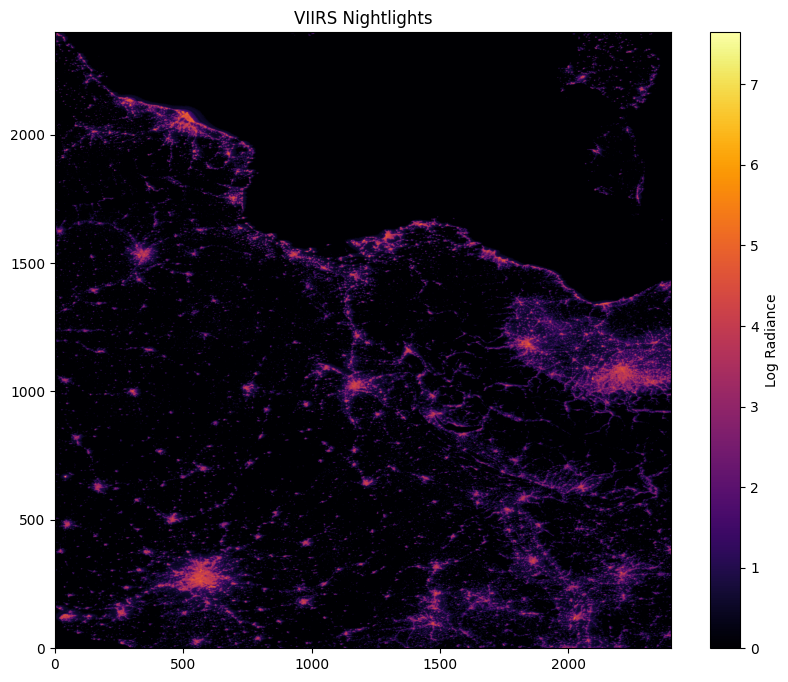

In [5]:
plt.figure(figsize=(10, 8))
plt.imshow(np.log1p(data), cmap="inferno", origin="lower")
plt.colorbar(label="Log Radiance")
plt.title("VIIRS Nightlights")
plt.show()

## 4. Convert Nightlights to a PNG Overlay for Folium

Folium's `ImageOverlay` accepts a PNG image positioned by its lat/lon bounding box. We render the nightlight raster with the inferno colormap and embed it as a semi-transparent overlay.

In [6]:
def raster_to_png_base64(data, cmap_name="inferno", fill_value=None, alpha=0.6):
    """
    Convert a 2D raster array to a base64-encoded RGBA PNG for use as a Folium ImageOverlay.
    Masked / fill values become fully transparent.
    """
    # Mask fill / nodata values (VIIRS typically uses 65535 or negative values)
    if fill_value is None:
        fill_value = 65535
    masked = np.ma.masked_where((data >= fill_value) | (data < 0), data.astype(float))

    # Log-scale normalise
    log_data = np.log1p(masked)
    vmin, vmax = log_data.min(), log_data.max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm(log_data.filled(0)))  # shape (H, W, 4)

    # Where data was masked, set alpha to 0 (fully transparent)
    rgba[..., 3] = np.where(masked.mask if np.ma.is_masked(masked) else False, 0.0, alpha)

    # Flip vertically so origin="lower" matches geographic north-up
    rgba_flipped = rgba[::-1, :, :]

    img_uint8 = (rgba_flipped * 255).astype(np.uint8)
    pil_img = Image.fromarray(img_uint8, mode="RGBA")

    buffer = BytesIO()
    pil_img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{encoded}"

png_url = raster_to_png_base64(data, cmap_name="inferno", alpha=0.6)
print("PNG overlay ready.")

PNG overlay ready.


## 5. Build the Interactive Overlay Map

Choose the year and months you want to display for bird sightings, then run the cell.

  Added bird heatmap for March (4 sightings)
  Added bird heatmap for April (15 sightings)
  Added bird heatmap for May (87 sightings)
  Added bird heatmap for June (37 sightings)

Map saved → nightlights_birds_2021.html



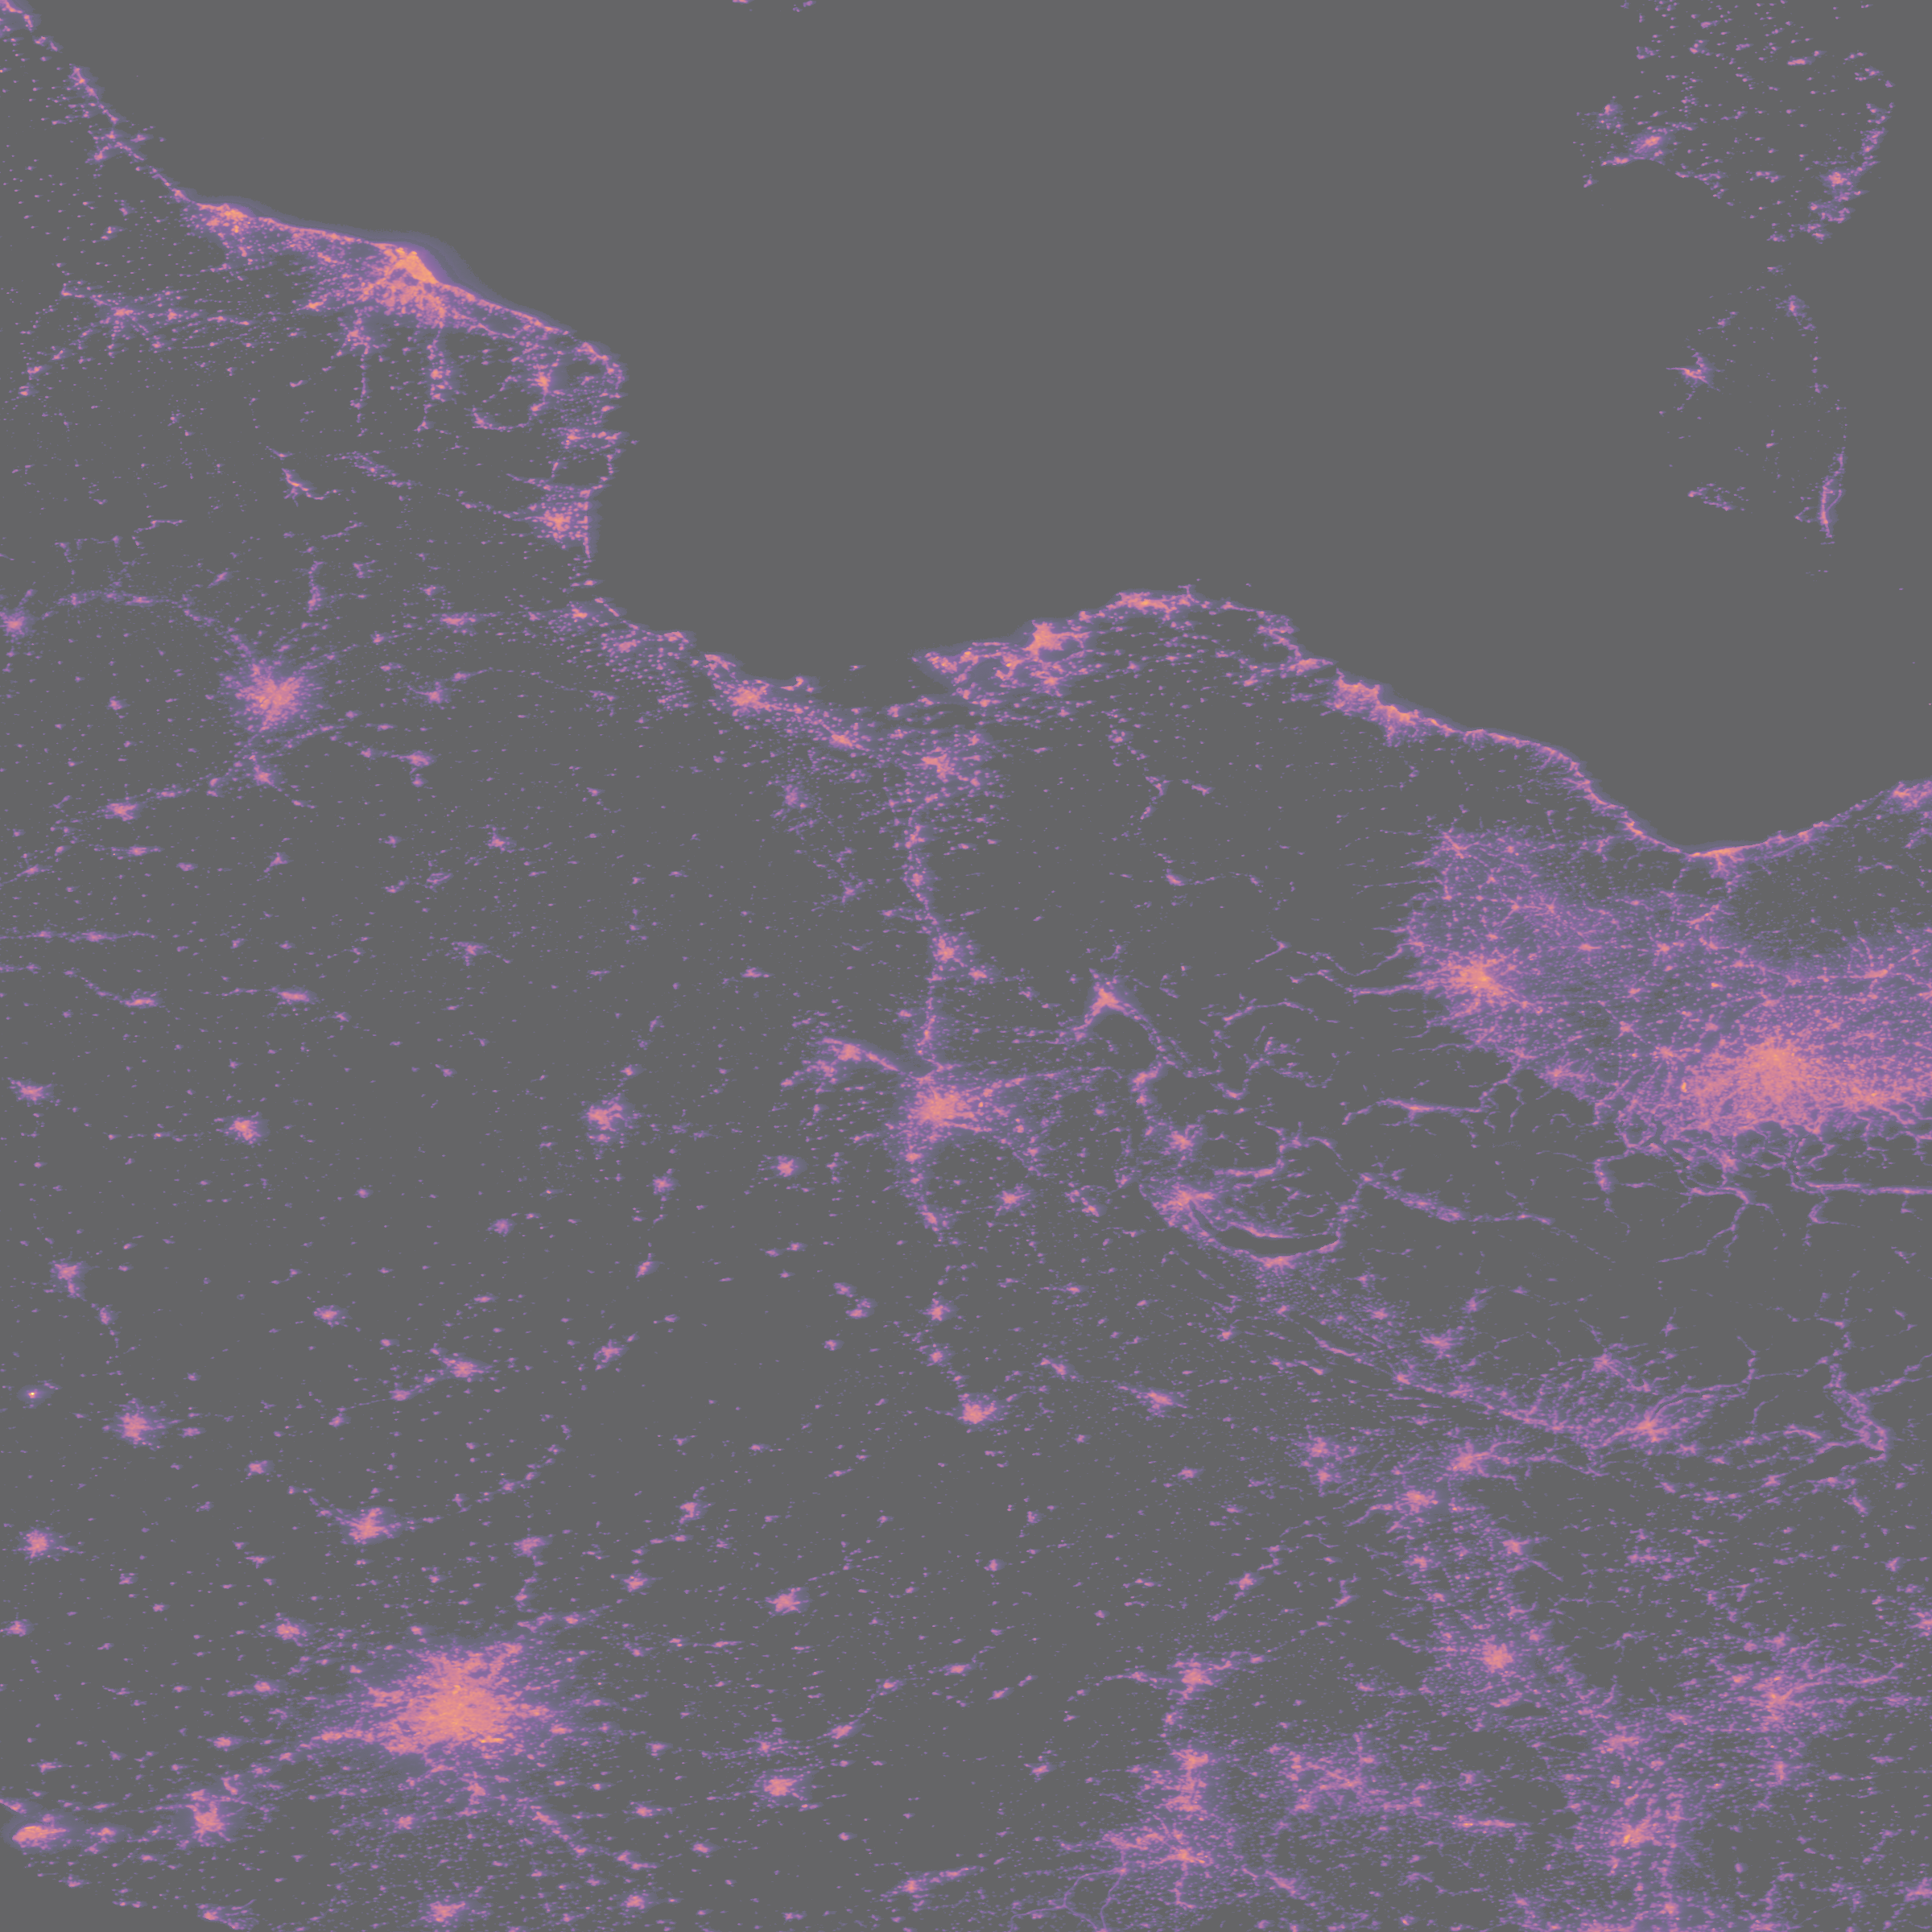

In [7]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
TARGET_YEAR   = 2021
TARGET_MONTHS = [3, 4, 5, 6]   # Spring migration: March–June
# ────────────────────────────────────────────────────────────────────────────

# Bounding box of the HDF5 tile (used to position the image overlay)
lat_min, lat_max = float(lat.min()), float(lat.max())
lon_min, lon_max = float(lon.min()), float(lon.max())

# --- 5a. Base map ---
m = folium.Map(
    location=[52, 10],
    zoom_start=4,
    tiles="cartodbdark_matter",   # dark basemap makes nightlights pop
)

# --- 5b. Nightlights image overlay ---
folium.raster_layers.ImageOverlay(
    image=png_url,
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=1.0,          # alpha is already baked into the PNG
    name="VIIRS Nightlights",
    zindex=1,
).add_to(m)

# --- 5c. Bird sightings heatmap per month ---
for month in TARGET_MONTHS:
    df_month = df[(df['YEAR'] == TARGET_YEAR) & (df['MONTH'] == month)]
    if df_month.empty:
        print(f"  No data for month {month}, skipping.")
        continue

    heat_data = df_month[['LATITUDE', 'LONGITUDE', 'OBSERVATION COUNT']].values.tolist()

    month_name = pd.Timestamp(year=TARGET_YEAR, month=month, day=1).strftime("%B")
    layer = folium.FeatureGroup(name=f"Birds – {month_name} {TARGET_YEAR}", show=(month == TARGET_MONTHS[0]))

    HeatMap(
        heat_data,
        radius=12,
        blur=8,
        min_opacity=0.4,
        gradient={0.2: "#00ffff", 0.5: "#00ff00", 0.8: "yellow", 1.0: "white"},
    ).add_to(layer)

    layer.add_to(m)
    print(f"  Added bird heatmap for {month_name} ({len(df_month):,} sightings)")

# --- 5d. Layer control so you can toggle nightlights / months ---
folium.LayerControl(collapsed=False).add_to(m)

# --- 5e. Save ---
out_file = f"nightlights_birds_{TARGET_YEAR}.html"
m.save(out_file)
print(f"\nMap saved → {out_file}")
m   # displays inline in Jupyter

## 6. (Optional) Multi-tile Nightlight Mosaic

If you have **multiple HDF5 tiles** covering Europe, loop over them and add one `ImageOverlay` per tile. Each tile has its own lat/lon bounds stored inside the file.

In [ ]:
# Example: load all .h5 files from the folder and add each as an overlay
# Uncomment and run if you have multiple tiles.

m_mosaic = folium.Map(location=[52, 10], zoom_start=4, tiles="cartodbdark_matter")

for fname in sorted(os.listdir(folder_path_h5)):
    if not fname.endswith(".h5"):
        continue
    fp = os.path.join(folder_path_h5, fname)
    with h5py.File(fp, "r") as f:
        tile_data = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"][:]
        tile_lat  = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lat"][:]
        tile_lon  = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lon"][:]

    tile_png = raster_to_png_base64(tile_data, cmap_name="inferno", alpha=0.6)
    folium.raster_layers.ImageOverlay(
        image=tile_png,
        bounds=[[tile_lat.min(), tile_lon.min()], [tile_lat.max(), tile_lon.max()]],
        opacity=1.0,
        name=fname,
    ).add_to(m_mosaic)
    print(f"Added tile: {fname}")

# Add bird heatmap on top
df_spring = df[(df['YEAR'] == TARGET_YEAR) & (df['MONTH'].isin(TARGET_MONTHS))]
HeatMap(df_spring[['LATITUDE','LONGITUDE','OBSERVATION COUNT']].values.tolist(),
        radius=12, blur=8, min_opacity=0.4).add_to(m_mosaic)

folium.LayerControl().add_to(m_mosaic)
m_mosaic.save("nightlights_birds_mosaic.html")
print("Mosaic map saved.")
m_mosaic

/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_54295/3949689197.py:12: RuntimeWarning: invalid value encountered in log1p
  log_data = np.log1p(masked)


Added tile: VNP46A4.A2017001.h16v03.002.2025104183958.h5
Added tile: VNP46A4.A2017001.h16v04.002.2025104185717.h5
Added tile: VNP46A4.A2017001.h17v02.002.2025105145833.h5
Added tile: VNP46A4.A2017001.h17v03.002.2025104185502.h5
Added tile: VNP46A4.A2017001.h17v04.002.2025104185200.h5
Added tile: VNP46A4.A2017001.h17v05.002.2025104185341.h5
Added tile: VNP46A4.A2017001.h18v02.002.2025105145647.h5
Added tile: VNP46A4.A2017001.h18v03.002.2025104183740.h5
Added tile: VNP46A4.A2017001.h18v04.002.2025104183925.h5
Added tile: VNP46A4.A2017001.h18v05.002.2025104183935.h5
Added tile: VNP46A4.A2017001.h19v02.002.2025105145611.h5
Added tile: VNP46A4.A2017001.h19v03.002.2025104183852.h5
Added tile: VNP46A4.A2017001.h19v04.002.2025104183858.h5
Added tile: VNP46A4.A2017001.h19v05.002.2025104183940.h5
Added tile: VNP46A4.A2017001.h20v01.002.2025105145148.h5
Added tile: VNP46A4.A2017001.h20v02.002.2025105145424.h5
Added tile: VNP46A4.A2017001.h20v03.002.2025104183903.h5
Added tile: VNP46A4.A2017001.h2